# Installing Ultralytics library

In [1]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 19.0 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Unzip the folder:

In [2]:
!unzip "/content/archive.zip" -d "/content/dataset"

Streaming output truncated to the last 5000 lines.
  inflating: /content/dataset/train/5/00005_00053_00010.png  
  inflating: /content/dataset/train/5/00005_00053_00011.png  
  inflating: /content/dataset/train/5/00005_00053_00012.png  
  inflating: /content/dataset/train/5/00005_00053_00013.png  
  inflating: /content/dataset/train/5/00005_00053_00014.png  
  inflating: /content/dataset/train/5/00005_00053_00015.png  
  inflating: /content/dataset/train/5/00005_00053_00016.png  
  inflating: /content/dataset/train/5/00005_00053_00017.png  
  inflating: /content/dataset/train/5/00005_00053_00018.png  
  inflating: /content/dataset/train/5/00005_00053_00019.png  
  inflating: /content/dataset/train/5/00005_00053_00020.png  
  inflating: /content/dataset/train/5/00005_00053_00021.png  
  inflating: /content/dataset/train/5/00005_00053_00022.png  
  inflating: /content/dataset/train/5/00005_00053_00023.png  
  inflating: /content/dataset/train/5/00005_00053_00024.png  
  inflating: /conte

# Reqiured Library:

In [5]:
# Importing Important Library:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.layers import GlobalAveragePooling2D

In [41]:
batch_size = 32
class_mode = 'categorical'
page_dir = '/content/dataset/Train'
target_size = (30, 30)

# Loading the data:

In [51]:
# Loading the data:
train_datagen = ImageDataGenerator(rescale = 1./255,
                                   rotation_range=10,
                                   zoom_range=0.15,
                                   width_shift_range=0.1,
                                   height_shift_range=0.1,
                                   shear_range=0.15,
                                   horizontal_flip=False,
                                   vertical_flip=False,
                                   fill_mode="nearest",
                                   validation_split = 0.2)

val_datagen = ImageDataGenerator(rescale = 1./255,
                                 validation_split = 0.2)

train_gen = train_datagen.flow_from_directory(page_dir,
                                  target_size = target_size,
                                  batch_size = batch_size,
                                  class_mode = class_mode,
                                  subset = 'training',
                                  shuffle = True)

val_gen = val_datagen.flow_from_directory(page_dir,
                                        target_size = target_size,
                                        batch_size = batch_size,
                                        class_mode = class_mode,
                                        subset = 'validation',
                                        shuffle = False)

Found 31368 images belonging to 43 classes.
Found 7841 images belonging to 43 classes.


# Building the model:

## Model_CNNa_1:

In [ ]:
# Building the model1:
# Step 5 : Model Builder Function

model = Sequential()
model.add(Conv2D(16, kernel_size = (5, 5), activation = 'relu', input_shape = (30, 30, 3)))
model.add(Conv2D(32, kernel_size = (5, 5), activation = 'relu'))
model.add(MaxPooling2D(2, 2))

model.add(Conv2D(64, kernel_size = (3, 3), activation = 'relu'))
model.add(Conv2D(128, kernel_size = (3,3), activation = 'relu'))
model.add(MaxPooling2D(2, 2))

model.add(Flatten())

model.add(Dense(512, activation = 'relu'))
model.add(Dropout(0.5))

model.add(Dense(43, activation = 'softmax'))



/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# model compile:

optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
model.compile(optimizer = optimizer, loss = 'categorical_crossentropy', metrics = ['accuracy'])


In [ ]:
# Early Stopping :
early_stop = EarlyStopping(monitor = 'val_loss', patience = 5, restore_best_weights = True)
model_checkpoint_callback = ModelCheckpoint(monitor = 'val_accuracy',
                                            filepath = 'best_model.h5',
                                            mode = 'max',
                                            save_best_only = True,
                                            verbose = 1)

In [ ]:
# Model training :
history1 = model.fit(train_gen, epochs = 30, validation_data = val_gen, callbacks = [early_stop, model_checkpoint_callback])

Epoch 1/30
980/981 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.2839 - loss: 2.5558
Epoch 1: val_accuracy improved from None to 0.83599, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
981/981 ━━━━━━━━━━━━━━━━━━━━ 48s 43ms/step - accuracy: 0.4941 - loss: 1.7192 - val_accuracy: 0.8360 - val_loss: 0.5442
Epoch 2/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.8254 - loss: 0.5473
Epoch 2: val_accuracy improved from 0.83599 to 0.91889, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
981/981 ━━━━━━━━━━━━━━━━━━━━ 38s 39ms/step - accuracy: 0.8573 - loss: 0.4455 - val_accuracy: 0.9189 - val_loss: 0.3126
Epoch 3/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9148 - loss: 0.2769
Epoch 3: val_accuracy improved from 0.91889 to 0.93011, saving model to best_model.h5



Epoch 3: finished saving model to best_model.h5
981/981 ━━━━━━━━━━━━━━━━━━━━ 39s 39ms/step - accuracy: 0.9216 - loss: 0.2499 - val_accuracy: 0.9301 - val_loss: 0.2634
Epoch 4/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.9419 - loss: 0.1921
Epoch 4: val_accuracy improved from 0.93011 to 0.95842, saving model to best_model.h5



Epoch 4: finished saving model to best_model.h5
981/981 ━━━━━━━━━━━━━━━━━━━━ 37s 37ms/step - accuracy: 0.9426 - loss: 0.1862 - val_accuracy: 0.9584 - val_loss: 0.1742
Epoch 5/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.9534 - loss: 0.1492
Epoch 5: val_accuracy did not improve from 0.95842
981/981 ━━━━━━━━━━━━━━━━━━━━ 37s 38ms/step - accuracy: 0.9555 - loss: 0.1452 - val_accuracy: 0.9528 - val_loss: 0.1776
Epoch 6/30
979/981 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.9636 - loss: 0.1238
Epoch 6: val_accuracy did not improve from 0.95842
981/981 ━━━━━━━━━━━━━━━━━━━━ 37s 38ms/step - accuracy: 0.9625 - loss: 0.1277 - val_accuracy: 0.9498 - val_loss: 0.1713
Epoch 7/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.9705 - loss: 0.0995
Epoch 7: val_accuracy did not improve from 0.95842
981/981 ━━━━━━━━━━━━━━━━━━━━ 38s 39ms/step - accuracy: 0.9694 - loss: 0.1022 - val_accuracy: 0.9571 - val_loss: 0.1648
Epoch 8/30
980/981 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accura


Epoch 8: finished saving model to best_model.h5
981/981 ━━━━━━━━━━━━━━━━━━━━ 38s 39ms/step - accuracy: 0.9711 - loss: 0.0960 - val_accuracy: 0.9630 - val_loss: 0.1662
Epoch 9/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.9737 - loss: 0.0914
Epoch 9: val_accuracy did not improve from 0.96301
981/981 ━━━━━━━━━━━━━━━━━━━━ 36s 37ms/step - accuracy: 0.9745 - loss: 0.0871 - val_accuracy: 0.9369 - val_loss: 0.2809
Epoch 10/30
980/981 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.9742 - loss: 0.0842
Epoch 10: val_accuracy improved from 0.96301 to 0.96620, saving model to best_model.h5



Epoch 10: finished saving model to best_model.h5
981/981 ━━━━━━━━━━━━━━━━━━━━ 36s 37ms/step - accuracy: 0.9746 - loss: 0.0846 - val_accuracy: 0.9662 - val_loss: 0.1401
Epoch 11/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.9761 - loss: 0.0798
Epoch 11: val_accuracy did not improve from 0.96620
981/981 ━━━━━━━━━━━━━━━━━━━━ 37s 38ms/step - accuracy: 0.9765 - loss: 0.0793 - val_accuracy: 0.9510 - val_loss: 0.1839
Epoch 12/30
980/981 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.9779 - loss: 0.0720
Epoch 12: val_accuracy improved from 0.96620 to 0.96952, saving model to best_model.h5



Epoch 12: finished saving model to best_model.h5
981/981 ━━━━━━━━━━━━━━━━━━━━ 37s 38ms/step - accuracy: 0.9770 - loss: 0.0764 - val_accuracy: 0.9695 - val_loss: 0.1582
Epoch 13/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.9793 - loss: 0.0638
Epoch 13: val_accuracy did not improve from 0.96952
981/981 ━━━━━━━━━━━━━━━━━━━━ 37s 38ms/step - accuracy: 0.9802 - loss: 0.0655 - val_accuracy: 0.9616 - val_loss: 0.1728
Epoch 14/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.9820 - loss: 0.0589
Epoch 14: val_accuracy did not improve from 0.96952
981/981 ━━━━━━━━━━━━━━━━━━━━ 37s 38ms/step - accuracy: 0.9819 - loss: 0.0616 - val_accuracy: 0.9656 - val_loss: 0.1672
Epoch 15/30
980/981 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.9801 - loss: 0.0670
Epoch 15: val_accuracy did not improve from 0.96952
981/981 ━━━━━━━━━━━━━━━━━━━━ 36s 37ms/step - accuracy: 0.9813 - loss: 0.0638 - val_accuracy: 0.9676 - val_loss: 0.1711


In [ ]:
# Getting model summary:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 16)     │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 22, 22, 32)     │        12,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 11, 11, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 9, 9, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       590,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 43)             │        22,059 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,156,387 (8.23 MB)

 Trainable params: 718,795 (2.74 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,437,592 (5.48 MB)

In [ ]:
# Getting Accuracy and loss :
acc = history1.history['accuracy']
val_acc = history1.history['val_accuracy']
loss = history1.history['loss']
val_loss = history1.history['val_loss']
print(f'Training Accuracy : {acc[-1]}')
print(f'Validation Accuracy : {val_acc[-1]}')
print(f'Training Loss : {loss[-1]}')
print(f'Validation Loss : {val_loss[-1]}')

Training Accuracy : 0.9813185334205627
Validation Accuracy : 0.9676061868667603
Training Loss : 0.06382804363965988
Validation Loss : 0.17107470333576202


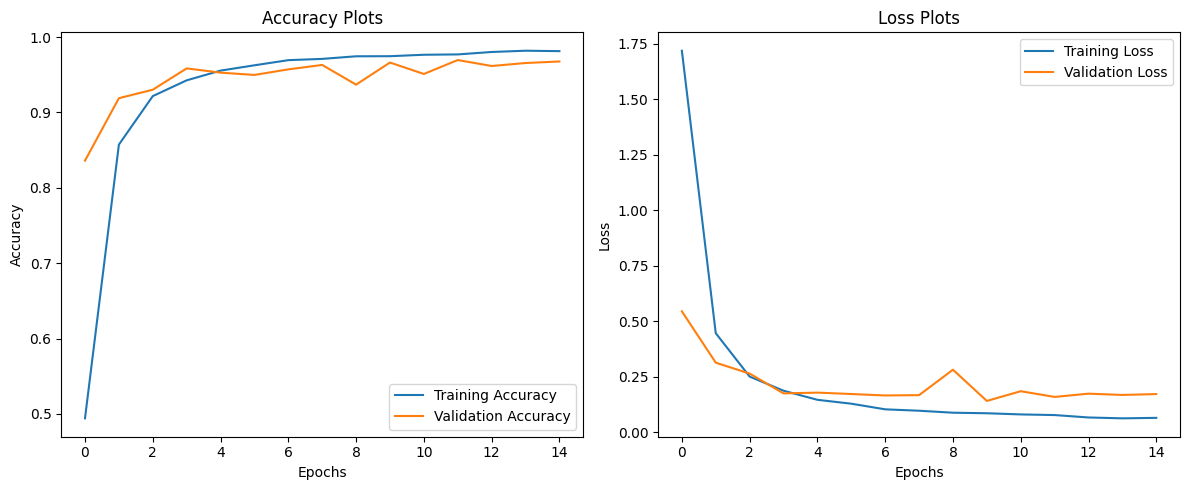

In [ ]:
# Plot the training and validation curve
plt.figure(figsize = (12, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history1.history['accuracy'], label = 'Training Accuracy')
plt.plot(history1.history['val_accuracy'], label = 'Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy Plots')

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history1.history['loss'], label = 'Training Loss')
plt.plot(history1.history['val_loss'], label = 'Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss Plots')

plt.tight_layout()
plt.show()

# Model_CNNs2:

In [ ]:
# model 2:
# Building the model1:
# Step 5 : Model Builder Function

model2 = Sequential()
model2.add(Conv2D(16, kernel_size = (5, 5), activation = 'relu', input_shape = (30, 30, 3)))
model2.add(Conv2D(32, kernel_size = (5, 5), activation = 'relu'))
model2.add(MaxPooling2D(2, 2))

model2.add(Conv2D(64, kernel_size = (3, 3), activation = 'relu'))
model2.add(Conv2D(128, kernel_size = (3,3), activation = 'relu'))
model2.add(MaxPooling2D(2, 2))

model2.add(Flatten())

model2.add(Dense(256, activation = 'relu'))
model2.add(Dropout(0.5))

model2.add(Dense(43, activation = 'softmax'))
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
#model compile:
new_optimizer = tf.keras.optimizers.Adam(learning_rate=0.001) # Create a new optimizer instance
model2.compile(optimizer = new_optimizer, loss = 'categorical_crossentropy', metrics = ['accuracy'])

In [ ]:
# Early Stopping :
early_stop = EarlyStopping(monitor = 'val_loss', patience = 5, restore_best_weights = True)
model_checkpoint_callback = ModelCheckpoint(monitor = 'val_accuracy',
                                            filepath = 'best_model2.h5',
                                            mode = 'max',
                                            save_best_only = True,
                                            verbose = 1)

In [ ]:
# Model training :
history2 = model2.fit(train_gen, epochs = 30, validation_data = val_gen, callbacks = [early_stop, model_checkpoint_callback])

Epoch 1/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.2809 - loss: 2.6008
Epoch 1: val_accuracy improved from None to 0.87132, saving model to best_model2.h5



Epoch 1: finished saving model to best_model2.h5
981/981 ━━━━━━━━━━━━━━━━━━━━ 46s 42ms/step - accuracy: 0.4932 - loss: 1.7425 - val_accuracy: 0.8713 - val_loss: 0.4782
Epoch 2/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.8128 - loss: 0.5967
Epoch 2: val_accuracy improved from 0.87132 to 0.92603, saving model to best_model2.h5



Epoch 2: finished saving model to best_model2.h5
981/981 ━━━━━━━━━━━━━━━━━━━━ 38s 39ms/step - accuracy: 0.8462 - loss: 0.4933 - val_accuracy: 0.9260 - val_loss: 0.2676
Epoch 3/30
980/981 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.9073 - loss: 0.3063
Epoch 3: val_accuracy improved from 0.92603 to 0.94133, saving model to best_model2.h5



Epoch 3: finished saving model to best_model2.h5
981/981 ━━━━━━━━━━━━━━━━━━━━ 37s 38ms/step - accuracy: 0.9170 - loss: 0.2740 - val_accuracy: 0.9413 - val_loss: 0.2359
Epoch 4/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.9374 - loss: 0.2021
Epoch 4: val_accuracy improved from 0.94133 to 0.94899, saving model to best_model2.h5



Epoch 4: finished saving model to best_model2.h5
981/981 ━━━━━━━━━━━━━━━━━━━━ 37s 38ms/step - accuracy: 0.9423 - loss: 0.1912 - val_accuracy: 0.9490 - val_loss: 0.1892
Epoch 5/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.9539 - loss: 0.1556
Epoch 5: val_accuracy did not improve from 0.94899
981/981 ━━━━━━━━━━━━━━━━━━━━ 37s 38ms/step - accuracy: 0.9545 - loss: 0.1542 - val_accuracy: 0.9487 - val_loss: 0.2099
Epoch 6/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.9603 - loss: 0.1370
Epoch 6: val_accuracy improved from 0.94899 to 0.94975, saving model to best_model2.h5



Epoch 6: finished saving model to best_model2.h5
981/981 ━━━━━━━━━━━━━━━━━━━━ 37s 38ms/step - accuracy: 0.9607 - loss: 0.1347 - val_accuracy: 0.9498 - val_loss: 0.2079
Epoch 7/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.9659 - loss: 0.1167
Epoch 7: val_accuracy did not improve from 0.94975
981/981 ━━━━━━━━━━━━━━━━━━━━ 37s 38ms/step - accuracy: 0.9675 - loss: 0.1116 - val_accuracy: 0.9458 - val_loss: 0.2767
Epoch 8/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.9685 - loss: 0.1144
Epoch 8: val_accuracy improved from 0.94975 to 0.95383, saving model to best_model2.h5



Epoch 8: finished saving model to best_model2.h5
981/981 ━━━━━━━━━━━━━━━━━━━━ 37s 38ms/step - accuracy: 0.9698 - loss: 0.1049 - val_accuracy: 0.9538 - val_loss: 0.1919
Epoch 9/30
980/981 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.9705 - loss: 0.1020
Epoch 9: val_accuracy did not improve from 0.95383
981/981 ━━━━━━━━━━━━━━━━━━━━ 37s 37ms/step - accuracy: 0.9732 - loss: 0.0917 - val_accuracy: 0.9513 - val_loss: 0.1781
Epoch 10/30
980/981 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.9732 - loss: 0.0929
Epoch 10: val_accuracy improved from 0.95383 to 0.96174, saving model to best_model2.h5



Epoch 10: finished saving model to best_model2.h5
981/981 ━━━━━━━━━━━━━━━━━━━━ 38s 39ms/step - accuracy: 0.9749 - loss: 0.0857 - val_accuracy: 0.9617 - val_loss: 0.1793
Epoch 11/30
980/981 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.9787 - loss: 0.0727
Epoch 11: val_accuracy did not improve from 0.96174
981/981 ━━━━━━━━━━━━━━━━━━━━ 37s 38ms/step - accuracy: 0.9786 - loss: 0.0746 - val_accuracy: 0.9512 - val_loss: 0.2528
Epoch 12/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.9761 - loss: 0.0871
Epoch 12: val_accuracy improved from 0.96174 to 0.96595, saving model to best_model2.h5



Epoch 12: finished saving model to best_model2.h5
981/981 ━━━━━━━━━━━━━━━━━━━━ 38s 38ms/step - accuracy: 0.9775 - loss: 0.0835 - val_accuracy: 0.9659 - val_loss: 0.1766
Epoch 13/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9808 - loss: 0.0676
Epoch 13: val_accuracy did not improve from 0.96595
981/981 ━━━━━━━━━━━━━━━━━━━━ 38s 39ms/step - accuracy: 0.9809 - loss: 0.0675 - val_accuracy: 0.9629 - val_loss: 0.1976
Epoch 14/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9814 - loss: 0.0680
Epoch 14: val_accuracy did not improve from 0.96595
981/981 ━━━━━━━━━━━━━━━━━━━━ 39s 39ms/step - accuracy: 0.9827 - loss: 0.0624 - val_accuracy: 0.9638 - val_loss: 0.2143
Epoch 15/30
980/981 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9827 - loss: 0.0644
Epoch 15: val_accuracy did not improve from 0.96595
981/981 ━━━━━━━━━━━━━━━━━━━━ 38s 39ms/step - accuracy: 0.9818 - loss: 0.0661 - val_accuracy: 0.9622 - val_loss: 0.1524
Epoch 16/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


Epoch 19: finished saving model to best_model2.h5
981/981 ━━━━━━━━━━━━━━━━━━━━ 37s 38ms/step - accuracy: 0.9853 - loss: 0.0541 - val_accuracy: 0.9676 - val_loss: 0.1759
Epoch 20/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.9838 - loss: 0.0617
Epoch 20: val_accuracy did not improve from 0.96761
981/981 ━━━━━━━━━━━━━━━━━━━━ 37s 38ms/step - accuracy: 0.9842 - loss: 0.0595 - val_accuracy: 0.9594 - val_loss: 0.2832


In [ ]:
# Getting model summary:
model2.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_16 (Conv2D)              │ (None, 26, 26, 16)     │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 22, 22, 32)     │        12,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 11, 11, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 9, 9, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 43)             │        11,051 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 412,619 (1.57 MB)

 Trainable params: 412,619 (1.57 MB)

 Non-trainable params: 0 (0.00 B)

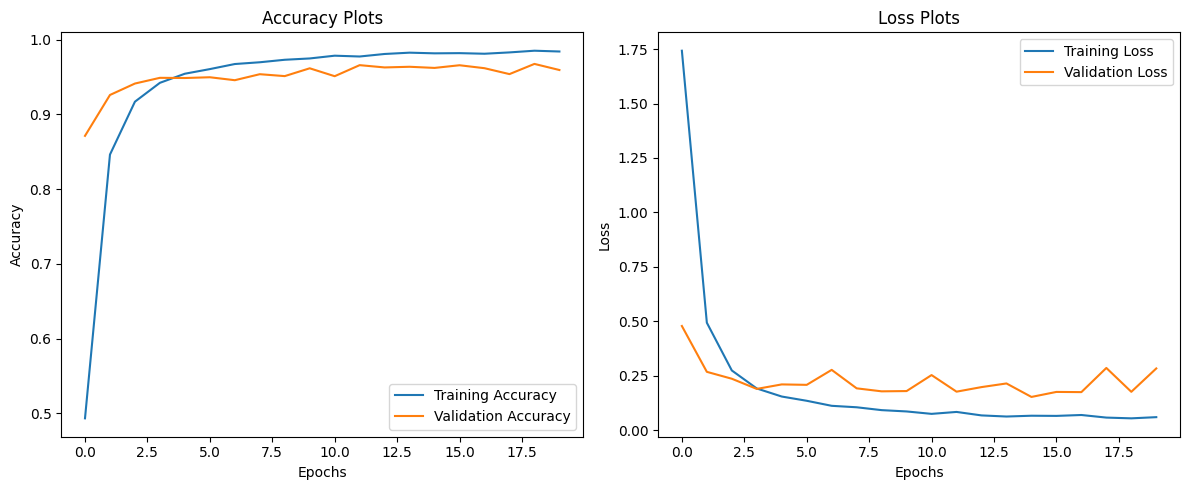

In [ ]:
# Plot the training and validation curve
plt.figure(figsize = (12, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history2.history['accuracy'], label = 'Training Accuracy')
plt.plot(history2.history['val_accuracy'], label = 'Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy Plots')

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history2.history['loss'], label = 'Training Loss')
plt.plot(history2.history['val_loss'], label = 'Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss Plots')

plt.tight_layout()
plt.show()


In [ ]:
# Getting Accuracy and loss :
acc = history2.history['accuracy']
val_acc = history2.history['val_accuracy']
loss = history2.history['loss']
val_loss = history2.history['val_loss']
print(f'Training Accuracy : {acc[-1]}')
print(f'Validation Accuracy : {val_acc[-1]}')
print(f'Training Loss : {loss[-1]}')
print(f'Validation Loss : {val_loss[1]}')

Training Accuracy : 0.9842196106910706
Validation Accuracy : 0.9594439268112183
Training Loss : 0.059503789991140366
Validation Loss : 0.26763227581977844


#Third model

In [ ]:
# final model:
# Model Building:

model3 = Sequential()
model3.add(Conv2D(filters = 16, kernel_size=(3, 3), activation='relu', input_shape=(30,30,3)))
model3.add(Conv2D(filters = 32, kernel_size=(3 ,3), activation='relu'))
model3.add(MaxPooling2D(pool_size=(2, 2)))
model3.add(BatchNormalization(axis=-1))

model3.add(Conv2D(filters = 64, kernel_size=(3, 3), activation='relu'))
model3.add(Conv2D(filters = 128, kernel_size=(3, 3), activation='relu'))
model3.add(MaxPooling2D(pool_size=(2, 2)))
model3.add(BatchNormalization(axis=-1))
model3.add(Flatten())

model3.add(Dense(512, activation='relu'))
model3.add(BatchNormalization())
model3.add(Dropout(rate=0.5))
model3.add(Dense(43, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# model compilation:
new_optimizer_model3 = tf.keras.optimizers.Adam(learning_rate=0.001)
model3.compile(optimizer = new_optimizer_model3, loss = 'categorical_crossentropy', metrics = ['accuracy'])

In [ ]:
model3.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_20 (Conv2D)              │ (None, 28, 28, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 26, 26, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 13, 13, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 9, 9, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 4, 4, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 43)             │        22,059 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,171,275 (4.47 MB)

 Trainable params: 1,169,931 (4.46 MB)

 Non-trainable params: 1,344 (5.25 KB)

In [ ]:
# model train:
history3 = model3.fit(train_gen, epochs = 30, validation_data = val_gen, callbacks = [early_stop, model_checkpoint_callback])

Epoch 1/30
980/981 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.5556 - loss: 1.7842
Epoch 1: val_accuracy did not improve from 0.96761
981/981 ━━━━━━━━━━━━━━━━━━━━ 49s 44ms/step - accuracy: 0.7457 - loss: 0.9298 - val_accuracy: 0.9098 - val_loss: 0.3052
Epoch 2/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9318 - loss: 0.2205
Epoch 2: val_accuracy did not improve from 0.96761
981/981 ━━━━━━━━━━━━━━━━━━━━ 41s 42ms/step - accuracy: 0.9402 - loss: 0.1903 - val_accuracy: 0.9117 - val_loss: 0.3216
Epoch 3/30
980/981 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.9581 - loss: 0.1356
Epoch 3: val_accuracy did not improve from 0.96761
981/981 ━━━━━━━━━━━━━━━━━━━━ 38s 38ms/step - accuracy: 0.9602 - loss: 0.1287 - val_accuracy: 0.9070 - val_loss: 0.3442
Epoch 4/30
980/981 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9685 - loss: 0.0997
Epoch 4: val_accuracy did not improve from 0.96761
981/981 ━━━━━━━━━━━━━━━━━━━━ 40s 40ms/step - accuracy: 0.9688 - loss: 0.0982 - val_accuracy

In [ ]:
# save the model:
model3.save('best_model_3.h5')

In [ ]:
# Getting Accuracy and loss :
acc = history3.history['accuracy']
val_acc = history3.history['val_accuracy']
loss = history3.history['loss']
val_loss = history3.history['val_loss']
print(f'Training Accuracy : {acc[-1]}')
print(f'Validation Accuracy : {val_acc[-1]}')
print(f'Training Loss : {loss[-1]}')
print(f'Validation Loss : {val_loss[-1]}')

Training Accuracy : 0.9832950830459595
Validation Accuracy : 0.9580410718917847
Training Loss : 0.05330592021346092
Validation Loss : 0.1797073632478714


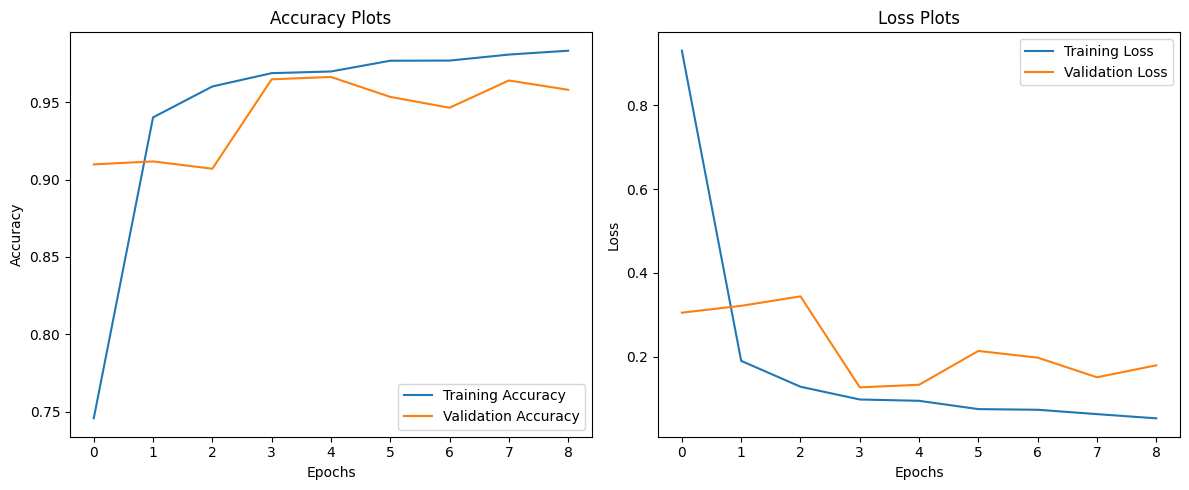

In [ ]:
# Plot the training and validation curve
plt.figure(figsize = (12, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history3.history['accuracy'], label = 'Training Accuracy')
plt.plot(history3.history['val_accuracy'], label = 'Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy Plots')

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history3.history['loss'], label = 'Training Loss')
plt.plot(history3.history['val_loss'], label = 'Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss Plots')

plt.tight_layout()
plt.show()


In [ ]:
labels = { 0:'Speed limit (20km/h)',
            1:'Speed limit (30km/h)',
            2:'Speed limit (50km/h)',
            3:'Speed limit (60km/h)',
            4:'Speed limit (70km/h)',
            5:'Speed limit (80km/h)',
            6:'End of speed limit (80km/h)',
            7:'Speed limit (100km/h)',
            8:'Speed limit (120km/h)',
            9:'No passing',
            10:'No passing veh over 3.5 tons',
            11:'Right-of-way at intersection',
            12:'Priority road',
            13:'Yield',
            14:'Stop',
            15:'No vehicles',
            16:'Veh > 3.5 tons prohibited',
            17:'No entry',
            18:'General caution',
            19:'Dangerous curve left',
            20:'Dangerous curve right',
            21:'Double curve',
            22:'Bumpy road',
            23:'Slippery road',
            24:'Road narrows on the right',
            25:'Road work',
            26:'Traffic signals',
            27:'Pedestrians',
            28:'Children crossing',
            29:'Bicycles crossing',
            30:'Beware of ice/snow',
            31:'Wild animals crossing',
            32:'End speed + passing limits',
            33:'Turn right ahead',
            34:'Turn left ahead',
            35:'Ahead only',
            36:'Go straight or right',
            37:'Go straight or left',
            38:'Keep right',
            39:'Keep left',
            40:'Roundabout mandatory',
            41:'End of no passing',
            42:'End no passing veh > 3.5 tons' }

/tmp/ipykernel_12710/2744831439.py:11: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image_fromarray = Image.fromarray(image, 'RGB')


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 500ms/step
--------------------
Predicted Sign is : Speed limit (30km/h)
--------------------


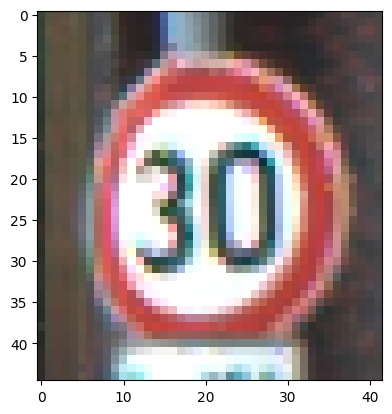

In [ ]:
import cv2
from PIL import Image
model_path = "/content/best_model.h5"
loaded_model = tf.keras.models.load_model(model_path)

import matplotlib.pyplot as plt
import numpy as np

image = cv2.imread("/content/00001.png")

image_fromarray = Image.fromarray(image, 'RGB')
resize_image = image_fromarray.resize((30, 30))
expand_input = np.expand_dims(resize_image,axis=0)
input_data = np.array(expand_input)
input_data = input_data/255

pred = loaded_model.predict(input_data)
result = pred.argmax()
result = labels[result]
print("--------------------")
print("Predicted Sign is :", result)
print("--------------------")
rgb_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.imshow(rgb_image)


# MobileNETV2:

In [ ]:
# using  a pretrained model1:
base_model = tf.keras.applications.MobileNetV2(include_top = False,
                                         input_shape = (32, 32, 3),
                                         weights = 'imagenet')
base_model.trainable = False

/tmp/ipykernel_12710/4005413639.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(include_top = False,


In [ ]:
target_size = (32, 32)
batch_size = 32
class_mode = 'categorical'
# Loading the data:
train_datagen = ImageDataGenerator(rescale = 1./255,
                                   rotation_range=10,
                                   zoom_range=0.15,
                                   width_shift_range=0.1,
                                   height_shift_range=0.1,
                                   shear_range=0.15,
                                   horizontal_flip=False,
                                   vertical_flip=False,
                                   fill_mode="nearest",
                                   validation_split = 0.2)

val_datagen = ImageDataGenerator(rescale = 1./255,
                                 validation_split = 0.2)

train_gen = train_datagen.flow_from_directory(page_dir,
                                  target_size = target_size,
                                  batch_size = batch_size,
                                  class_mode = class_mode,
                                  subset = 'training',
                                  shuffle = True)

val_gen = val_datagen.flow_from_directory(page_dir,
                                        target_size = target_size,
                                        batch_size = batch_size,
                                        class_mode = class_mode,
                                        subset = 'validation',
                                        shuffle = True)

Found 31368 images belonging to 43 classes.
Found 7841 images belonging to 43 classes.


In [ ]:
# Adding final layer:
model4 = Sequential()
model4.add(base_model)
model4.add(GlobalAveragePooling2D())
model4.add(Dense(512, activation = 'relu'))
model4.add(Dropout(0.5))
model4.add(Dense(43, activation = 'softmax'))

In [ ]:
# compile the model:
model4.compile(optimizer = 'Adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])

In [ ]:
# getting model2 summary:
model4.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 1, 1, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 43)             │        22,059 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,935,915 (11.20 MB)

 Trainable params: 677,931 (2.59 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
# Traing the model2:
history4 = model4.fit(train_gen, epochs = 15, validation_data = val_gen)


Epoch 1/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 84s 68ms/step - accuracy: 0.2317 - loss: 2.7018 - val_accuracy: 0.2361 - val_loss: 2.6901
Epoch 2/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 44s 42ms/step - accuracy: 0.2894 - loss: 2.4043 - val_accuracy: 0.2394 - val_loss: 2.6467
Epoch 3/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 41s 42ms/step - accuracy: 0.3093 - loss: 2.3198 - val_accuracy: 0.2382 - val_loss: 2.6270
Epoch 4/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 41s 42ms/step - accuracy: 0.3199 - loss: 2.2704 - val_accuracy: 0.2548 - val_loss: 2.5978
Epoch 5/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 43s 43ms/step - accuracy: 0.3243 - loss: 2.2295 - val_accuracy: 0.2616 - val_loss: 2.6148
Epoch 6/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 41s 42ms/step - accuracy: 0.3399 - loss: 2.1963 - val_accuracy: 0.2553 - val_loss: 2.5988
Epoch 7/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 41s 42ms/step - accuracy: 0.3433 - loss: 2.1797 - val_accuracy: 0.2584 - val_loss: 2.5961
Epoch 8/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 41s 41ms/step - accuracy: 0.3435 - loss: 2.1674 - 

In [ ]:
# acc : 0.366
# loss : 2.08
#val_acc = 0.209
#val_loss = 2.61

In [ ]:
# save the model2 :
model4.save('model4.h5')

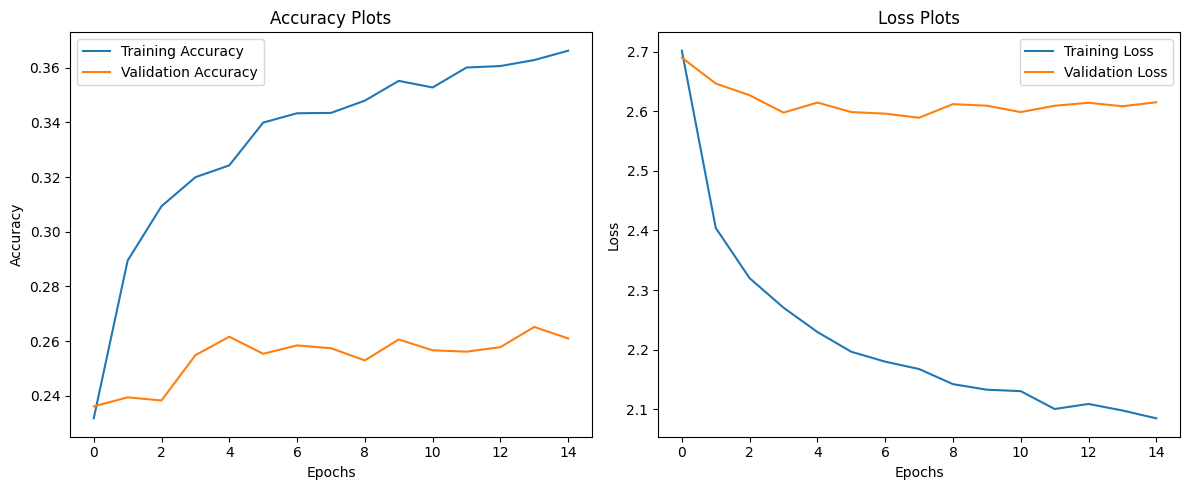

In [ ]:
# Plot the training and validation curve
plt.figure(figsize = (12, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history4.history['accuracy'], label = 'Training Accuracy')
plt.plot(history4.history['val_accuracy'], label = 'Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy Plots')

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history4.history['loss'], label = 'Training Loss')
plt.plot(history4.history['val_loss'], label = 'Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss Plots')

plt.tight_layout()
plt.show()

# ResNet50:

In [ ]:
# using  a pretrained model2:
base_model2 = tf.keras.applications.ResNet50(include_top = False,
                                         input_shape = (32, 32, 3),
                                         weights = 'imagenet')
base_model2.trainable = False

In [ ]:
# Adding final layer:
model5 = Sequential()
model5.add(base_model2)
model5.add(GlobalAveragePooling2D())
model5.add(Dense(512, activation = 'relu'))
model5.add(Dropout(0.5))
model5.add(Dense(43, activation = 'softmax'))

In [ ]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

In [ ]:
# compile the model:
model5.compile(optimizer = optimizer, loss = 'categorical_crossentropy', metrics = ['accuracy'])

In [ ]:
# getting model2 summary:
model5.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 1, 1, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 43)             │        22,059 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,658,859 (94.07 MB)

 Trainable params: 1,071,147 (4.09 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
# Training the model2:
history5 = model4.fit(train_gen, epochs = 15, validation_data = val_gen)

Epoch 1/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 43s 44ms/step - accuracy: 0.3690 - loss: 2.0768 - val_accuracy: 0.2637 - val_loss: 2.6062
Epoch 2/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 42s 43ms/step - accuracy: 0.3696 - loss: 2.0737 - val_accuracy: 0.2607 - val_loss: 2.6002
Epoch 3/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 53s 54ms/step - accuracy: 0.3728 - loss: 2.0655 - val_accuracy: 0.2600 - val_loss: 2.6013
Epoch 4/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 47s 48ms/step - accuracy: 0.3720 - loss: 2.0594 - val_accuracy: 0.2635 - val_loss: 2.6065
Epoch 5/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 43s 44ms/step - accuracy: 0.3703 - loss: 2.0583 - val_accuracy: 0.2635 - val_loss: 2.6168
Epoch 6/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 43s 44ms/step - accuracy: 0.3717 - loss: 2.0457 - val_accuracy: 0.2617 - val_loss: 2.6163
Epoch 7/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 81s 43ms/step - accuracy: 0.3718 - loss: 2.0480 - val_accuracy: 0.2604 - val_loss: 2.6203
Epoch 8/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 44s 44ms/step - accuracy: 0.3745 - loss: 2.0646 - 

In [ ]:
# Getting Accuracy and loss :
acc = history5.history['accuracy']
val_acc = history5.history['val_accuracy']
loss = history5.history['loss']
val_loss = history5.history['val_loss']
print(f'Training Accuracy : {acc[-1]}')
print(f'Validation Accuracy : {val_acc[-1]}')
print(f'Training Loss : {loss[-1]}')
print(f'Validation Loss : {val_loss[-1]}')

Training Accuracy : 0.38156720995903015
Validation Accuracy : 0.2662925720214844
Training Loss : 2.025404214859009
Validation Loss : 2.6255226135253906


In [ ]:
# save the model :
model5.save('model5.h5')

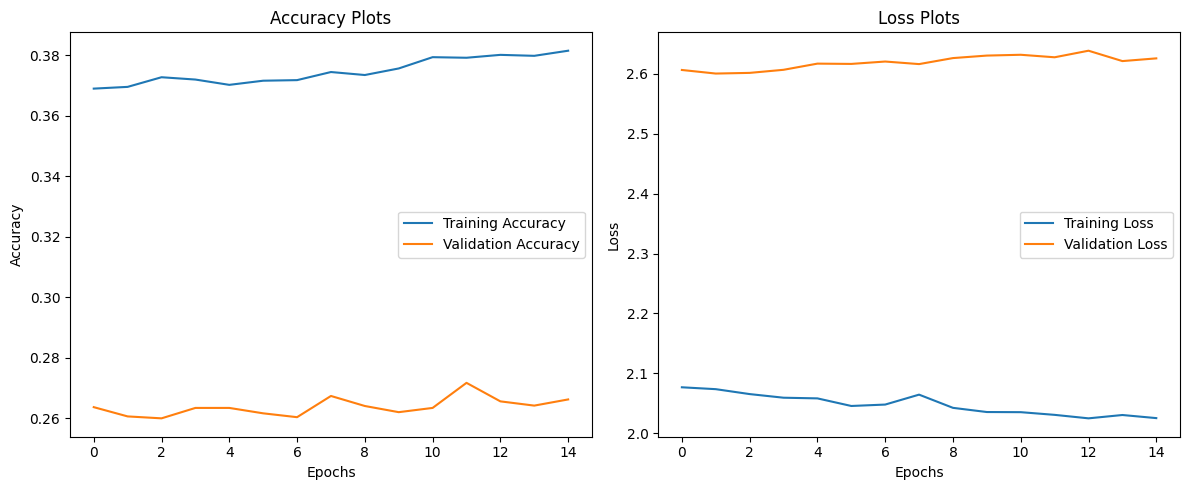

In [ ]:
# Plot the training and validation curve
plt.figure(figsize = (12, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history5.history['accuracy'], label = 'Training Accuracy')
plt.plot(history5.history['val_accuracy'], label = 'Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy Plots')

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history5.history['loss'], label = 'Training Loss')
plt.plot(history5.history['val_loss'], label = 'Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss Plots')

plt.tight_layout()
plt.show()

# Structred Pandas DataFrame:

In [ ]:
import pandas as pd

d = { 'Models' : ['CNNs_model1', 'CNNs_model2','CNNs_model2', 'MobileNETV2', 'ResNet50'],
    'Layers' : [10, 10, 13, 4, 4],
     'neurons' : [565, 299, 565,565, 565],
     'Val_Accuracy' : [0.96, 0.95, 0.95, 0.21, 0.266],
     'Train_Accuracy' : [0.98, 0.98, 0.98, 0.37, 0.38],
     'Val_Loss' : [0.08, 0.06, 0.05, 2.61, 2.62],
     'Train_Loss' : [0.17, 0.26, 0.17, 2.08, 2.02],
     }



In [ ]:
model_performence = pd.DataFrame(d)
model_performence

,Models,Layers,neurons,Val_Accuracy,Train_Accuracy,Val_Loss,Train_Loss
0,CNNs_model1,10,565,0.960,0.98,0.08,0.17
1,CNNs_model2,10,299,0.950,0.98,0.06,0.26
2,CNNs_model2,13,565,0.950,0.98,0.05,0.17
3,MobileNETV2,4,565,0.210,0.37,2.61,2.08
4,ResNet50,4,565,0.266,0.38,2.62,2.02


In [1]:
d1 = { 'Models' : ['CNNs_model2', 'MobileNETv2', 'ResNet50'],
       'Val_Accuracy' : [0.95, 0.21, 0.266],
       'Train_Accuracy' : [0.98, 0.37, 0.38],
       'Val_Loss' : [0.05, 2.61, 2.62],
       'Train_Loss' : [0.17, 2.08, 2.02],
       'File_size(MB)' : [4.47, 11.02, 94],
       'Inference_Time(ms)_GPU' : [40, 42, 46]

     }


In [3]:
import pandas as pd
model_performence1 = pd.DataFrame(d1)
model_performence1

,Models,Val_Accuracy,Train_Accuracy,Val_Loss,Train_Loss,File_size(MB),Inference_Time(ms)_GPU
0,CNNs_model2,0.950,0.98,0.05,0.17,4.47,40
1,MobileNETv2,0.210,0.37,2.61,2.08,11.02,42
2,ResNet50,0.266,0.38,2.62,2.02,94.00,46


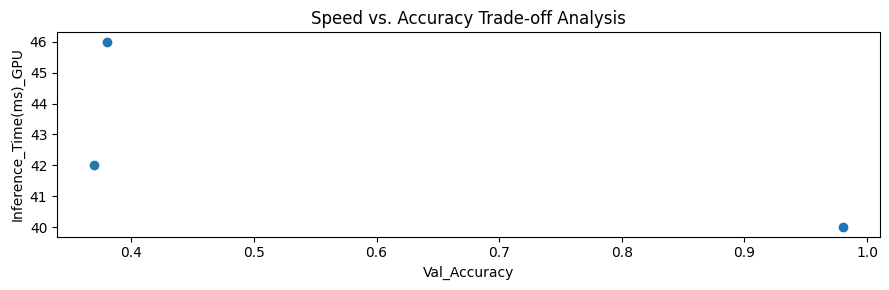

In [9]:
import matplotlib.pyplot as plt
plt.figure(figsize = (9, 3))
plt.scatter(model_performence1['Train_Accuracy'], model_performence1['Inference_Time(ms)_GPU'])
plt.xlabel('Val_Accuracy')
plt.ylabel('Inference_Time(ms)_GPU')
plt.title('Speed vs. Accuracy Trade-off Analysis')
plt.tight_layout()
plt.show()

# cunfusion matrix:

In [59]:
# loaded saved model:
model = tf.keras.models.load_model('/content/best_model2 (1).h5')

In [60]:
predictions = model.predict(val_gen)
y_pred = np.argmax(predictions, axis=1)

246/246 ━━━━━━━━━━━━━━━━━━━━ 9s 37ms/step


In [61]:
y_pred

array([ 0,  0,  0, ..., 42, 42, 42])

In [62]:
len(y_pred)

7841

In [63]:
from sklearn.metrics import confusion_matrix, classification_report

true_classes = val_gen.classes
class_labels = list(val_gen.class_indices.keys())

cm = confusion_matrix(true_classes, y_pred)
print(cm)

[[ 40   1   0 ...   0   0   0]
 [  0 438   0 ...   0   0   0]
 [  0   0 402 ...   0   0   0]
 ...
 [  0   1   0 ... 276   5   0]
 [  0   0   0 ...   1 281   0]
 [  0   0   0 ...   0   0 293]]


In [64]:
true_classes

array([ 0,  0,  0, ..., 42, 42, 42], dtype=int32)

In [65]:
print(classification_report(true_classes, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.95      0.98        42
           1       0.95      0.99      0.97       444
           2       1.00      1.00      1.00       402
           3       0.93      0.97      0.95       264
           4       0.99      1.00      1.00       420
           5       0.97      0.99      0.98       432
           6       0.99      1.00      1.00       156
           7       0.97      0.77      0.86       126
           8       1.00      1.00      1.00        84
           9       1.00      0.99      0.99       222
          10       0.98      1.00      0.99       240
          11       0.96      0.55      0.70        42
          12       0.99      0.94      0.97       450
          13       0.96      0.99      0.97        72
          14       0.98      0.98      0.98        66
          15       1.00      0.99      0.99        78
          16       0.82      0.77      0.80       102
          17       0.93    

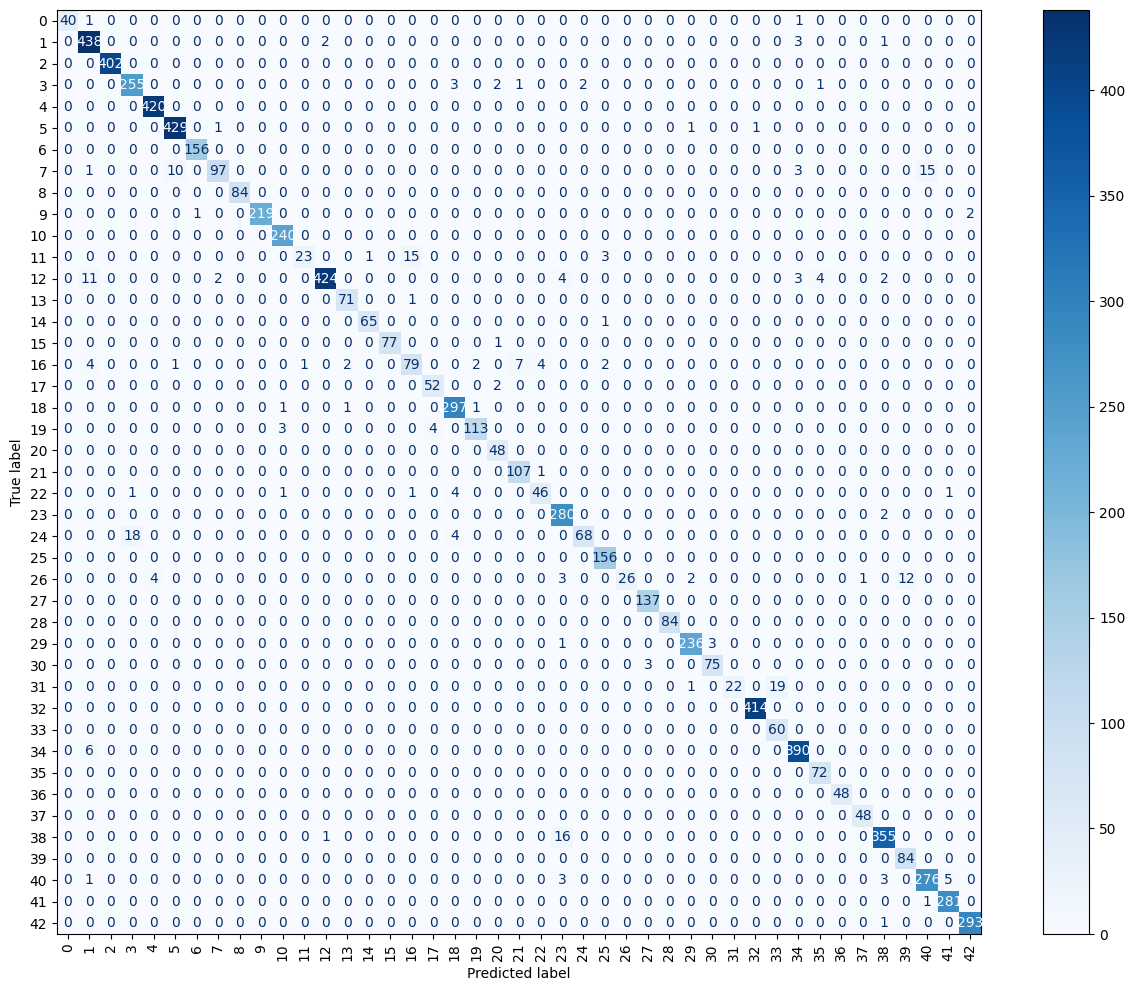

In [66]:
from sklearn.metrics import ConfusionMatrixDisplay

# For 43 classes, it's better not to display_labels=True
cm = confusion_matrix(val_gen.classes, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
fig, ax = plt.subplots(figsize=(16, 12))
disp.plot(ax=ax, cmap='Blues', colorbar=True)
plt.xticks(rotation=90)
plt.show()